In [64]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/retail-sales-prediction-and-demand-forecasting/white.csv
/kaggle/input/retail-sales-prediction-and-demand-forecasting/blue.csv
/kaggle/input/retail-sales-prediction-and-demand-forecasting/red.csv
/kaggle/input/retail-sales-prediction-and-demand-forecasting/train.csv
/kaggle/input/retail-sales-prediction-and-demand-forecasting/test.csv
/kaggle/input/retail-sales-prediction-and-demand-forecasting/yellow.csv


Setup Complete
(8041, 9) (3045, 9)


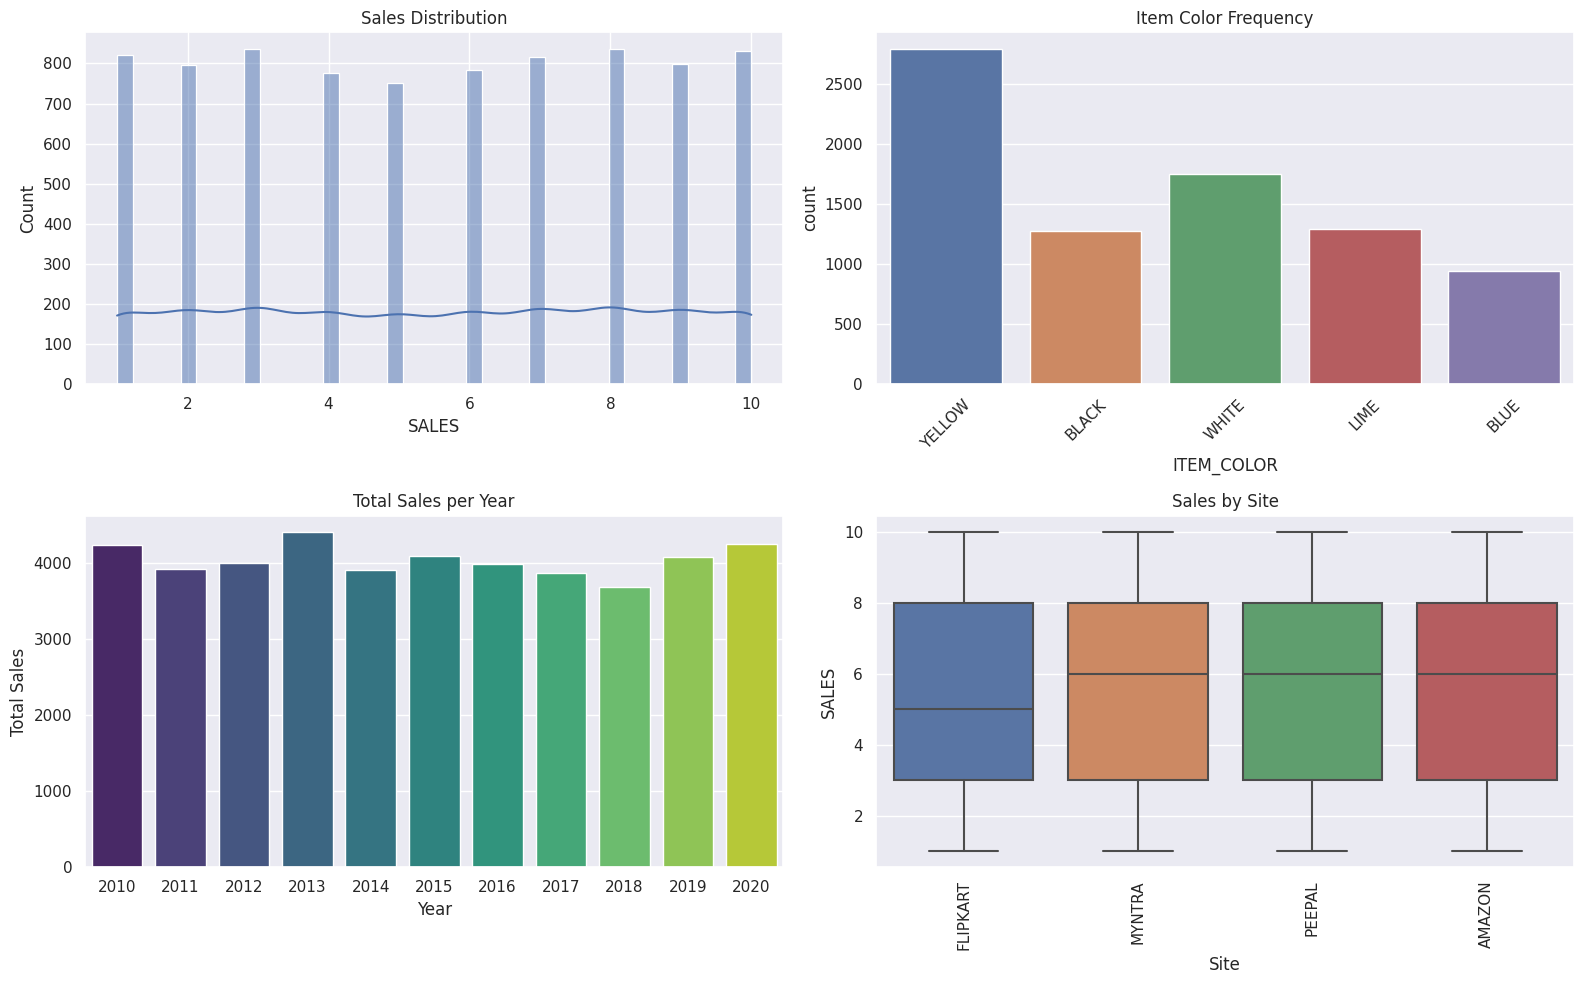

Missing Values in Data: 
item_id                          0
item_name                        0
sales date                       0
MRP                              0
revenue generated             3045
ITEM_COLOR                       0
Site                             0
SALES                            0
Year                             0
source                           0
revenue generated per sale    8041
dtype: int64
--------------------------------------------
Information about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11086 entries, 0 to 11085
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   item_id                     11086 non-null  object 
 1   item_name                   11086 non-null  object 
 2   sales date                  11086 non-null  object 
 3   MRP                         11086 non-null  int64  
 4   revenue generated           8041 non-null   floa

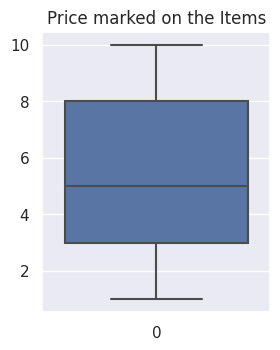

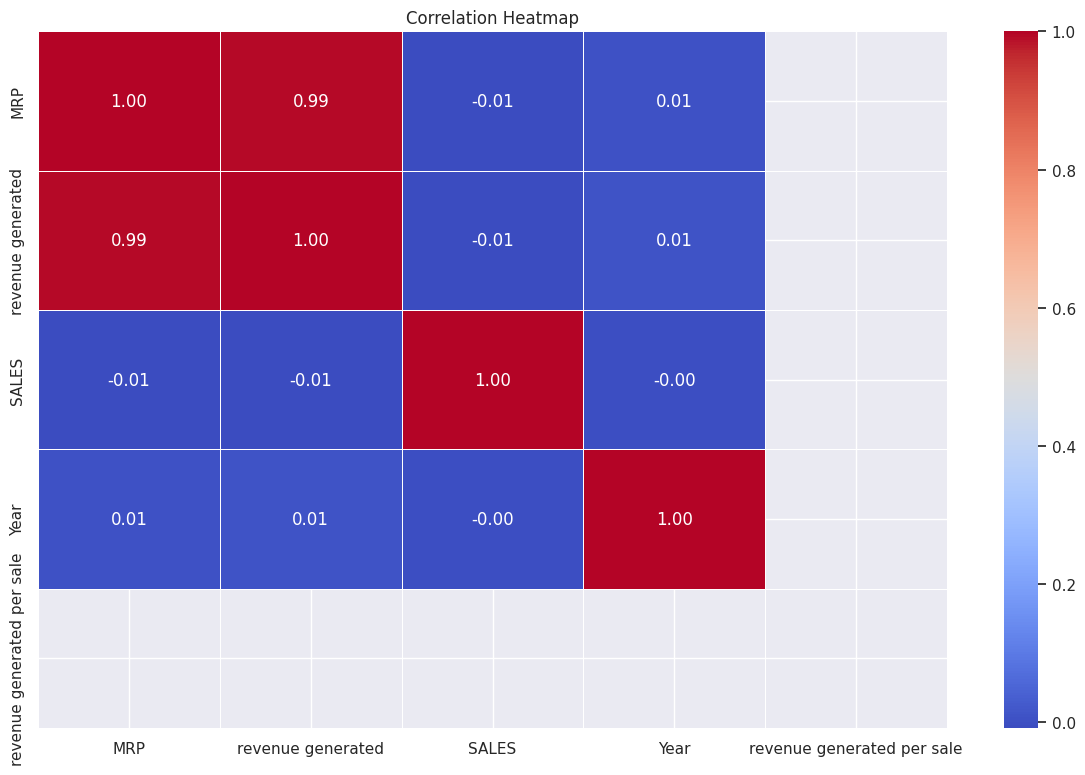

      item_id          item_name ITEM_COLOR      Site  SALES  Year source  \
0       RYSBA   SLEEVLESS TSHIRT      WHITE  FLIPKART      7  2010  train   
1       RYHBA            HOODIES       LIME    MYNTRA      8  2010  train   
2       RYSBA   SLEEVLESS TSHIRT       BLUE    MYNTRA      9  2010  train   
3       RXABC  ROUND NECK TSHIRT     YELLOW  FLIPKART     10  2010  train   
4       RXABC  ROUND NECK TSHIRT     YELLOW    PEEPAL      8  2010  train   
...       ...                ...        ...       ...    ...   ...    ...   
11081   RYHBA            HOODIES      WHITE    MYNTRA      6  2020   test   
11082   RYCBA       POLO T SHIRT      BLACK    PEEPAL      8  2020   test   
11083   RYCBA       POLO T SHIRT       BLUE  FLIPKART      5  2020   test   
11084   RYCBA       POLO T SHIRT      BLACK    PEEPAL      3  2020   test   
11085   RYHBA            HOODIES     YELLOW    PEEPAL      8  2020   test   

       revenue generated per sale  
0                             NaN  
1  

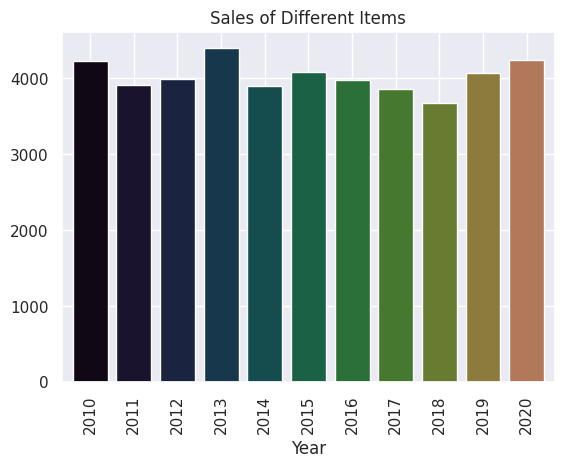

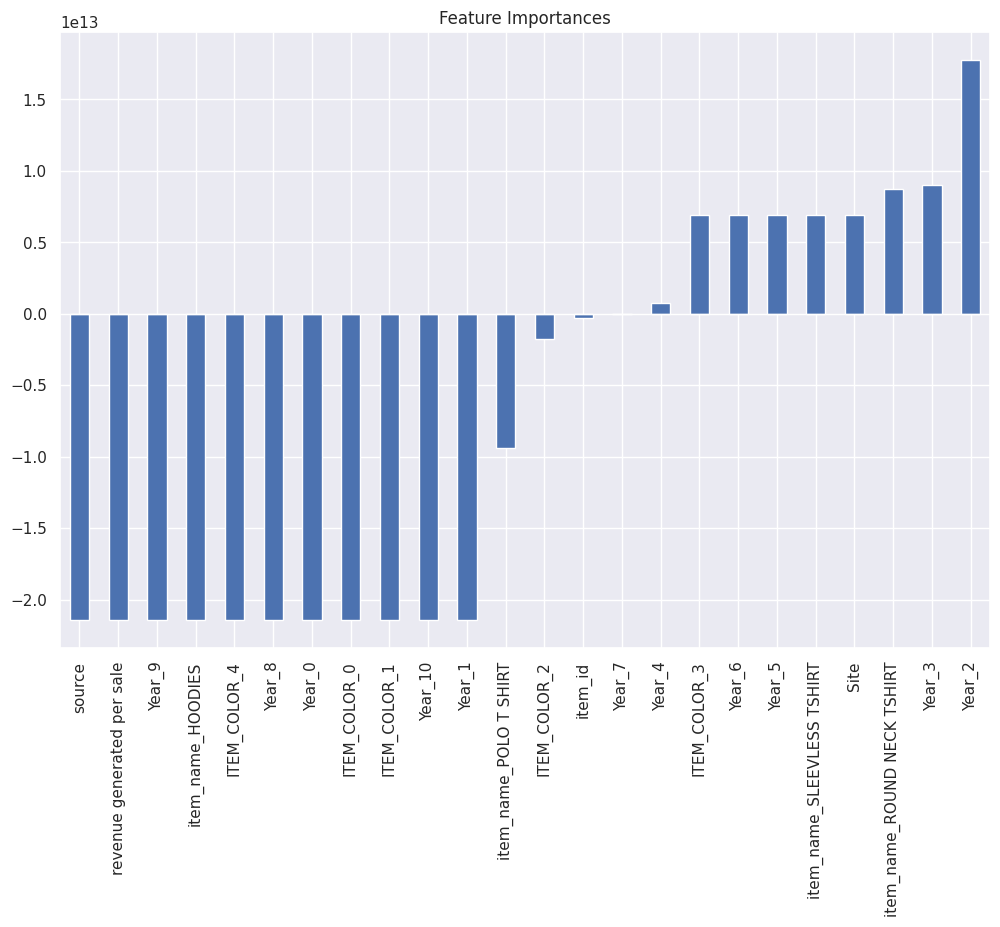

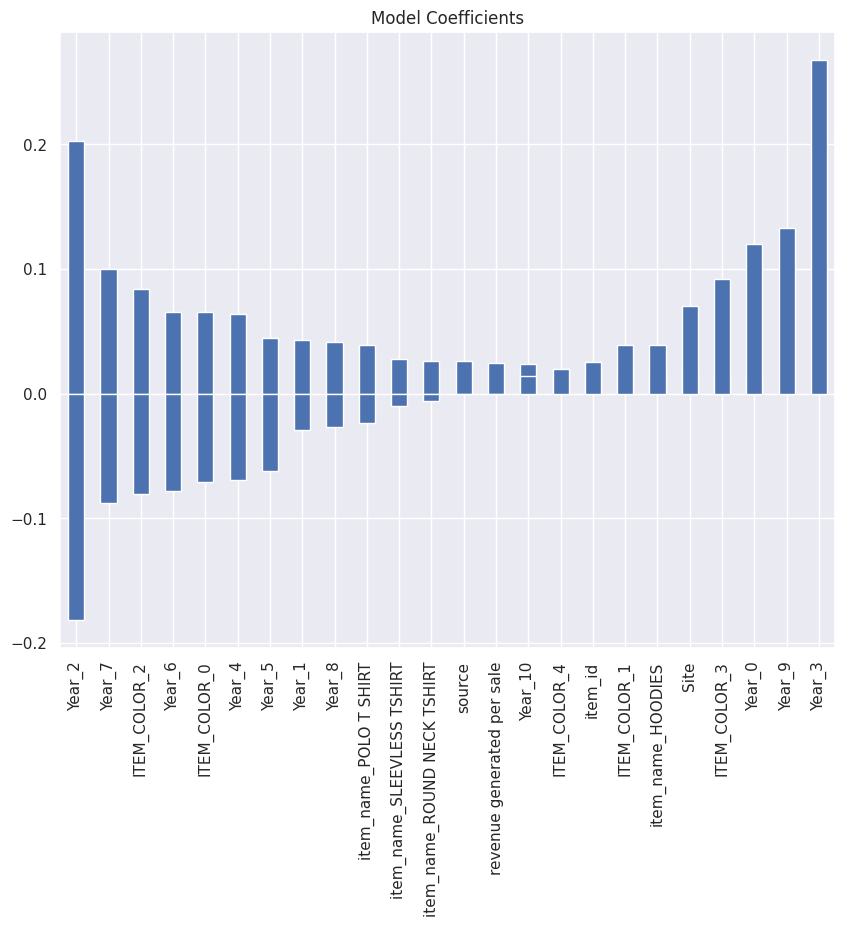

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')
print('Setup Complete')

# Load the datasets
train = pd.read_csv('/kaggle/input/retail-sales-prediction-and-demand-forecasting/train.csv')
test = pd.read_csv('/kaggle/input/retail-sales-prediction-and-demand-forecasting/test.csv')
print(train.shape, test.shape)

#Combine Dataset for feature engineering
train['source']= 'train'
test['source'] = 'test'
data = pd.concat([train,test],ignore_index=True)

# Quick Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')
plt.figure(figsize=(16, 10))

# Plot 1: SALES distribution
plt.subplot(2, 2, 1)
sns.histplot(train['SALES'], bins=40, kde=True)
plt.title('Sales Distribution')
plt.xlabel('SALES')

# Plot 2: Item color distribution
plt.subplot(2, 2, 2)
sns.countplot(data=data[data['source'] == 'train'], x='ITEM_COLOR', order=data['ITEM_COLOR'].value_counts().index)
plt.title('Item Color Frequency')
plt.xticks(rotation=45)

# Plot 3: Yearly Sales Trend
plt.subplot(2, 2, 3)
yearly_sales = train.groupby('Year')['SALES'].sum()
sns.barplot(x=yearly_sales.index, y=yearly_sales.values, palette='viridis')
plt.title('Total Sales per Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')

# Plot 4: Sales by Site
plt.subplot(2, 2, 4)
sns.boxplot(x='Site', y='SALES', data=train)
plt.xticks(rotation=90)
plt.title('Sales by Site')

plt.tight_layout()
plt.show()

print('Missing Values in Data: \n%s' % data.apply(lambda x: sum(x.isna())))
print('--------------------------------------------')
print('Information about the data\n')
print(data.info())
print('--------------------------------------------')
print('Frequency of Categorical Variables: \n%s' %data.apply(lambda x : len(x.unique())) )

category = [x for x in data.dtypes.index if data.dtypes[x]=='object']
exclude_col = []
categorical_col = [x for x in category if x not in exclude_col]
for column in categorical_col:
    print('\nFrequency of Categories %s'  %column)
    print(data[column].value_counts())

data[['item_id','item_name']].head()

data.describe()


data.head()

plt.figure(1,figsize=(10,8))
plt.subplot(2,3,1)
sns.boxplot(data['SALES'])
plt.title("Price marked on the Items")

train = data.loc[data['source']=="train"]
test = data.loc[data['source']=="test"]

# Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_features = train.select_dtypes(include=[np.number])
corr_matrix = numeric_features.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

plt.figure(1,figsize=(14,10))
plt.subplot(2,2,1)
item_sales = train.groupby('Year').SALES.sum().astype(int)
item_sales.plot.bar(width=0.8,color=sns.color_palette('cubehelix',20))
plt.title("Sales of Different Items")

data=data.drop(['sales date'], axis = 1) 
data=data.drop(['revenue generated'], axis = 1) 
data=data.drop(['MRP'], axis = 1)

target  = 'SALES'
col = []

def drop_columns(value):
    return value.drop([],axis=1,inplace=True)
def drop_test_target():
    return test.drop('SALES',axis=1,inplace=True)

from sklearn.preprocessing import LabelEncoder
print(data)
label = LabelEncoder()
data['Site'] = label.fit_transform(data['Site'])
variable_modify = ['Year','item_id','ITEM_COLOR']
for i in variable_modify:
    data[i]=label.fit_transform(data[i])
data = pd.get_dummies(data,columns=['Year','item_name','ITEM_COLOR'])

train = data.loc[data['source']=="train"]
test = data.loc[data['source']=="test"]
drop_test_target()
drop_columns(train)
drop_columns(test)

from sklearn.model_selection import cross_val_score
from sklearn import metrics
def model_fit(alg, d_train, d_test, predictors, target,col, filename):
    #Fit the algorithm on the data
    alg.fit(d_train[predictors], d_train[target])
        
    #Predict training set:
    d_train_predictions = alg.predict(d_train[predictors])
    
    #Remember the target had been normalized
    sq_train = (d_train[target])**2
#Perform cross-validation:
    cv_score = cross_val_score(alg, d_train[predictors],sq_train , cv=20, scoring='neg_mean_squared_error')
    cv_score = np.sqrt(np.abs(cv_score))
    
    #Print model report:
    print("\nModel Report")
    print("RMSE : %.4g" % np.sqrt(metrics.mean_squared_error(sq_train.values,d_train_predictions)))
    print("CV Score : Mean - %.4g | Std - %.4g | Min - %.4g | Max - %.4g" % (np.mean(cv_score),np.std(cv_score),np.min(cv_score),np.max(cv_score)))
    
    #Predict on testing data:
    d_test[target] = alg.predict(d_test[predictors])
    
    #Export submission file:
    col.append(target)
    submission = pd.DataFrame({ x: d_test[x] for x in col})
    submission.to_csv(filename, index=False)

from sklearn.linear_model import LinearRegression
features = [x for x in train.columns if x not in [target]+col]
linear_algo = LinearRegression()
train=train.apply(LabelEncoder().fit_transform)
test=test.apply(LabelEncoder().fit_transform)
model_fit(linear_algo,train,test,features,target,col,'linear_regerssion.csv')

plt.figure(figsize=(12,8))
coef_1 = pd.Series(linear_algo.coef_, features).sort_values()
coef_1.plot(kind='bar', title='Model Coefficients')

from sklearn.tree import DecisionTreeRegressor
decision_algo = DecisionTreeRegressor(max_depth=15,min_samples_leaf=100)
model_fit(decision_algo,train,test,features,target,col,'decision_tree.csv')
coef_3 = pd.Series(decision_algo.feature_importances_,features).sort_values()
coef_3.plot.bar(title='Feature Importances')

from sklearn.ensemble import RandomForestRegressor
random_algo = RandomForestRegressor(n_estimators=400,max_depth=6,min_samples_leaf=100,n_jobs=4)
model_fit(random_algo,train,test,features,target,col,'random_forest.csv')
coef_4 = pd.Series(random_algo.feature_importances_,features).sort_values(ascending=False)
plt.figure(figsize=(10,8))
coef_4.plot.bar(title='Feature Importances')

#Ridge Regression
from sklearn.linear_model import Ridge
ridge_algo = Ridge(alpha=0.05)
model_fit(ridge_algo, train, test, features, target,col, 'ridge_regression.csv')
coef2 = pd.Series(ridge_algo.coef_, features).sort_values()
coef2.plot(kind='bar', title='Model Coefficients')

#XGBoost Model
from xgboost import XGBRegressor
xg_model = XGBRegressor(n_estimators=100,learning_rate=0.05)
xg_model.fit(train[features],train[target],early_stopping_rounds=5,eval_set=[(test[features],test[target])])
train_predictions = xg_model.predict(train[features])
# make predictions
predictions = xg_model.predict(test[features])
from sklearn.metrics import mean_absolute_error
print("Mean Absolute Error : " + str(mean_absolute_error(predictions, test[target])))
print("RMSE : %.4g" % np.sqrt(metrics.mean_squared_error((train[target]).values, train_predictions)))
col.append(target)
submission = pd.DataFrame({ x: test[x] for x in col})
submission.to_csv("xgboost.csv",index=False)